In [440]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score , mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

In [441]:
df = pd.read_csv('train.csv')
print(df.head())
print(df.describe())

            title  year     mileage transmission                    fuel  \
0  هیوندای، توسان  2014  175,000 km     اتوماتیک  9.6 لیتر در صد کیلومتر   
1      پراید، 131  1391  330,000 km      دنده ای  6.7 لیتر در صد کیلومتر   
2        پژو، 206  1398  132,000 km      دنده ای  6.4 لیتر در صد کیلومتر   
3    تیبا، هاچ بک  1396  103,000 km      دنده ای  6.9 لیتر در صد کیلومتر   
4       پژو، پارس  1401   37,000 km      دنده ای    7 لیتر در صد کیلومتر   

  body_color inside_color body_status  \
0       سفید        مارون    بدون رنگ   
1       سفید         سفید    بدون رنگ   
2       سفید      خاکستری    بدون رنگ   
3        آبی      خاکستری    بدون رنگ   
4    خاکستری          کرم    بدون رنگ   

                                         description      body_type    volume  \
0  مانیتور اندرویدی بدنه بدون لیسه کشی و روغن گیر...      crossover  2.4 لیتر   
1  ماشین شاستی سرشاستی پلمپ میباشد به شرط موتوری ...  passenger_car  1.3 لیتر   
2                                 خیلی تمیز فنی عالی 

In [442]:
df

,title,year,mileage,transmission,fuel,body_color,inside_color,body_status,description,body_type,volume,engine,acceleration,price
0,هیوندای، توسان,2014,"175,000 km",اتوماتیک,9.6 لیتر در صد کیلومتر,سفید,مارون,بدون رنگ,مانیتور اندرویدی بدنه بدون لیسه کشی و روغن گیر...,crossover,2.4 لیتر,4 سیلندر,10.4 ثانیه,"2,550,000,000"
1,پراید، 131,1391,"330,000 km",دنده ای,6.7 لیتر در صد کیلومتر,سفید,سفید,بدون رنگ,ماشین شاستی سرشاستی پلمپ میباشد به شرط موتوری ...,passenger_car,1.3 لیتر,4 سیلندر یورو3 (M13),13.8 ثانیه,"215,000,000"
2,پژو، 206,1398,"132,000 km",دنده ای,6.4 لیتر در صد کیلومتر,سفید,خاکستری,بدون رنگ,خیلی تمیز فنی عالی,hatchback,1.4 لیتر,4 سیلندر TU3,14.1 ثانیه,"445,000,000"
3,تیبا، هاچ بک,1396,"103,000 km",دنده ای,6.9 لیتر در صد کیلومتر,آبی,خاکستری,بدون رنگ,ماشین دارای دوربین دنده عقب،روکش صندلی نو،زاپا...,hatchback,1.5 لیتر,4 سیلندر M15,13 ثانیه,"310,000,000"
4,پژو، پارس,1401,"37,000 km",دنده ای,7 لیتر در صد کیلومتر,خاکستری,کرم,بدون رنگ,NaN,passenger_car,1.8 لیتر,4 سیلندر XU7 پلاس,12 ثانیه,"570,000,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15583,رانا، LX,1392,"230,000 km",دنده ای,6.9 لیتر در صد کیلومتر,قرمز,مشکی,چند لکه رنگ,موتور تازه تعمیر \r\nلاستیک نو,passenger_car,1.6 لیتر,4 سیلندر TU5 یورو4,12 ثانیه,"280,000,000"
15584,رانا، پلاس,1401,"50,000 km",دنده ای,6.9 لیتر در صد کیلومتر,مشکی,مشکی,بدون رنگ,NaN,passenger_car,1.6 لیتر,4 سیلندر TU5 یورو5,12 ثانیه,"495,000,000"
15585,پژو، 207,1402,"9,500 km",دنده ای,6.6 لیتر در صد کیلومتر,مشکی,مشکی,بدون رنگ,NaN,hatchback,1.6 لیتر,4 سیلندر TU5,11.6 ثانیه,"710,000,000"
15586,سیتروئن، زانتیا,1388,"178,000 km",دنده ای,7 لیتر در صد کیلومتر,سفید,خاکستری,چند لکه رنگ,ماشین فوق‌العاده تمیز و سالم فنی کاملا سالم و ...,passenger_car,2 لیتر,4 سیلندر XU10,9.5 ثانیه,"650,000,000"


In [443]:
print(df.isnull().sum())

title              0
year               0
mileage            0
transmission       0
fuel            1657
body_color         0
inside_color       0
body_status        0
description     2098
body_type          0
volume          1217
engine          1217
acceleration    1836
price              0
dtype: int64


In [444]:
for cols in df.columns:
    print(cols)
    print(len(df[cols].unique()))
    print(df[cols].unique())

title
232
<StringArray>
[         'هیوندای، توسان',              'پراید، 131',
                'پژو، 206',            'تیبا، هاچ بک',
               'پژو، پارس',               'لکسوس، RX',
                'پژو، 207',         'هیوندای، النترا',
                  'جک، S3',   'مزدا، 3 نیو صندوق دار',
 ...
              'مینی، کوپر',     'هیوندای، جنسیس کوپه',
           'هیوندای، ورنا',               'هایما، 7X',
 'تویوتا، یاریس صندوق دار',           'گریت وال، C30',
          'دنا، پلاس EF7P',          'کیا، سراتو کوپ',
        'دنا، پلاس جوانان',           'پاژن، چهار در']
Length: 232, dtype: str
year
77
[2014 1391 1398 1396 1401 2012 1400 1394 1388 2017 1402 1397 1392 1390
 1384 1386 1393 1389 1395 2018 2007 2009 1399 2016 2005 1387 1403 2015
 2008 2010 2006 2011 1383 1381 1977 1382 2013 1385 1372 1380 1373 2022
 2019 1980 1377 1366 2020 1376 1379 1978 1991 1975 1983 2001 1994 1378
 2002 2023 1374 1974 1375 1371 1363 1995 1992 1367 1358 1993 1984 1985
 1976 2003 1370 1971 1368 1355 199

phase 2:
data preprocessing

In [445]:
df["mileage"] = (
    df["mileage"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("km", "", regex=False)
    .str.replace("کارکرده", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.strip()
)

df["mileage"] = pd.to_numeric(df["mileage"], errors="coerce")

df["mileage"] = df["mileage"].fillna(df["mileage"].median())

In [446]:
column = 'fuel'
df[column] = (
    df[column]
    .astype(str)
    .str.replace("لیتر در صد کیلومتر", "", regex=False)
    .str.strip()
    .astype(float)
)
df[column] = df[column].fillna(df[column].median())

In [447]:
column = 'volume'
df[column] = (
    df[column]
    .astype(str)
    .str.replace("لیتر", "", regex=False)
    .str.strip()
    .astype(float)
)
df[column] = df[column].fillna(df[column].median())

In [448]:
column = 'acceleration'
df[column] = (
    df[column]
    .astype(str)
    .str.replace("ثانیه", "", regex=False)
    .str.replace("/", ".", regex=False)
    .str.strip()
    .astype(float)
)
df[column] = df[column].fillna(df[column].median())

In [449]:
def convert_year(year):
    if year > 1406:
        return year - 621

    return year


df["year"] = df["year"].apply(convert_year)

In [450]:
df['price'] = (
    df["price"]
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [451]:
df

,title,year,mileage,transmission,fuel,body_color,inside_color,body_status,description,body_type,volume,engine,acceleration,price
0,هیوندای، توسان,1393,175000.0,اتوماتیک,9.6,سفید,مارون,بدون رنگ,مانیتور اندرویدی بدنه بدون لیسه کشی و روغن گیر...,crossover,2.4,4 سیلندر,10.4,2.550000e+09
1,پراید، 131,1391,330000.0,دنده ای,6.7,سفید,سفید,بدون رنگ,ماشین شاستی سرشاستی پلمپ میباشد به شرط موتوری ...,passenger_car,1.3,4 سیلندر یورو3 (M13),13.8,2.150000e+08
2,پژو، 206,1398,132000.0,دنده ای,6.4,سفید,خاکستری,بدون رنگ,خیلی تمیز فنی عالی,hatchback,1.4,4 سیلندر TU3,14.1,4.450000e+08
3,تیبا، هاچ بک,1396,103000.0,دنده ای,6.9,آبی,خاکستری,بدون رنگ,ماشین دارای دوربین دنده عقب،روکش صندلی نو،زاپا...,hatchback,1.5,4 سیلندر M15,13.0,3.100000e+08
4,پژو، پارس,1401,37000.0,دنده ای,7.0,خاکستری,کرم,بدون رنگ,NaN,passenger_car,1.8,4 سیلندر XU7 پلاس,12.0,5.700000e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15583,رانا، LX,1392,230000.0,دنده ای,6.9,قرمز,مشکی,چند لکه رنگ,موتور تازه تعمیر \r\nلاستیک نو,passenger_car,1.6,4 سیلندر TU5 یورو4,12.0,2.800000e+08
15584,رانا، پلاس,1401,50000.0,دنده ای,6.9,مشکی,مشکی,بدون رنگ,NaN,passenger_car,1.6,4 سیلندر TU5 یورو5,12.0,4.950000e+08
15585,پژو، 207,1402,9500.0,دنده ای,6.6,مشکی,مشکی,بدون رنگ,NaN,hatchback,1.6,4 سیلندر TU5,11.6,7.100000e+08
15586,سیتروئن، زانتیا,1388,178000.0,دنده ای,7.0,سفید,خاکستری,چند لکه رنگ,ماشین فوق‌العاده تمیز و سالم فنی کاملا سالم و ...,passenger_car,2.0,4 سیلندر XU10,9.5,6.500000e+08


In [452]:
df = pd.get_dummies(df, columns=['transmission', 'body_type','body_status' ])

df = df.rename(columns={
    'transmission_اتوماتیک': 'automatic',
    'transmission_دنده ای': 'geer'
})

In [453]:
df[["title", "type"]] = (
    df["title"]
    .astype(str)
    .str.strip()
    .str.split("،", n=1, expand=True)
)

In [454]:
percentage_map = df["title"].value_counts(normalize=True)
df["title"] = df["title"].map(percentage_map)

percentage_map = df["type"].value_counts(normalize=True)
df["type"] = df["type"].map(percentage_map)

In [455]:
percentage_map = df['body_color'].value_counts(normalize=True)
df['body_color'] = df['body_color'].map(percentage_map)

In [456]:
df.drop(columns =['description', 'inside_color', 'engine'], inplace = True)

In [457]:
df

,title,year,mileage,fuel,body_color,volume,acceleration,price,automatic,geer,...,body_status_صافکاری بدون رنگ,body_status_چند لکه رنگ,body_status_کامل رنگ,body_status_کاپوت تعویض,body_status_کاپوت رنگ,body_status_گلگیر تعویض,body_status_گلگیر رنگ,body_status_یک درب رنگ,body_status_یک لکه رنگ,type
0,0.059918,1393,175000.0,9.6,0.537529,2.4,10.4,2.550000e+09,True,False,...,False,False,False,False,False,False,False,False,False,0.008596
1,0.054401,1391,330000.0,6.7,0.537529,1.3,13.8,2.150000e+08,False,True,...,False,False,False,False,False,False,False,False,False,0.018540
2,0.244547,1398,132000.0,6.4,0.537529,1.4,14.1,4.450000e+08,False,True,...,False,False,False,False,False,False,False,False,False,0.080767
3,0.021876,1396,103000.0,6.9,0.016038,1.5,13.0,3.100000e+08,False,True,...,False,False,False,False,False,False,False,False,False,0.014691
4,0.244547,1401,37000.0,7.0,0.055235,1.8,12.0,5.700000e+08,False,True,...,False,False,False,False,False,False,False,False,False,0.053118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15583,0.014370,1392,230000.0,6.9,0.007634,1.6,12.0,2.800000e+08,False,True,...,False,True,False,False,False,False,False,False,False,0.028740
15584,0.014370,1401,50000.0,6.9,0.204131,1.6,12.0,4.950000e+08,False,True,...,False,False,False,False,False,False,False,False,False,0.005838
15585,0.244547,1402,9500.0,6.6,0.204131,1.6,11.6,7.100000e+08,False,True,...,False,False,False,False,False,False,False,False,False,0.054016
15586,0.004106,1388,178000.0,7.0,0.537529,2.0,9.5,6.500000e+08,False,True,...,False,True,False,False,False,False,False,False,False,0.003015


statics

In [458]:
df.columns

Index(['title', 'year', 'mileage', 'fuel', 'body_color', 'volume',
       'acceleration', 'price', 'automatic', 'geer', 'body_type_coupe',
       'body_type_crossover', 'body_type_hatchback', 'body_type_passenger_car',
       'body_type_pickup', 'body_type_suv', 'body_type_van',
       'body_status_اتاق تعویض', 'body_status_بدون رنگ',
       'body_status_درب تعویض', 'body_status_دو درب رنگ',
       'body_status_دو لکه رنگ', 'body_status_دور رنگ',
       'body_status_صافکاری بدون رنگ', 'body_status_چند لکه رنگ',
       'body_status_کامل رنگ', 'body_status_کاپوت تعویض',
       'body_status_کاپوت رنگ', 'body_status_گلگیر تعویض',
       'body_status_گلگیر رنگ', 'body_status_یک درب رنگ',
       'body_status_یک لکه رنگ', 'type'],
      dtype='str')

In [459]:
numeric_columns = ['title', 'year', 'mileage', 'fuel', 'body_color', 'volume','acceleration', 'price']
statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Standard Deviation": df[numeric_columns].std()
})

statistics

,Mean,Median,Standard Deviation
title,8.347427e-02,4.689505e-02,9.303882e-02
year,1.395279e+03,1.396000e+03,5.597220e+00
mileage,1.198497e+05,9.500000e+04,1.048745e+05
fuel,7.541378e+00,7.200000e+00,1.373280e+00
body_color,3.393544e-01,5.375289e-01,2.215615e-01
volume,1.767998e+00,1.600000e+00,4.564316e-01
acceleration,1.163564e+01,1.160000e+01,1.914241e+00
price,1.328410e+09,6.650000e+08,1.976430e+09


In [460]:
covariance_matrix = df[numeric_columns].cov()

covariance_matrix

,title,year,mileage,fuel,body_color,volume,acceleration,price
title,8.656222e-03,-1.787511e-02,9.933822e+02,-2.348941e-02,2.940332e-04,-8.845398e-03,3.060605e-02,-4.521366e+07
year,-1.787511e-02,3.132888e+01,-4.298919e+05,-1.826587e+00,3.330206e-01,-6.539286e-01,2.403832e-01,-1.337462e+08
mileage,9.933822e+02,-4.298919e+05,1.099865e+10,2.239531e+04,-4.290482e+03,6.030739e+03,1.184025e+04,-2.900055e+13
fuel,-2.348941e-02,-1.826587e+00,2.239531e+04,1.885899e+00,-2.573794e-02,4.504935e-01,-1.179814e-01,5.347185e+08
body_color,2.940332e-04,3.330206e-01,-4.290482e+03,-2.573794e-02,4.908949e-02,-1.001474e-02,3.153033e-02,-2.807065e+07
volume,-8.845398e-03,-6.539286e-01,6.030739e+03,4.504935e-01,-1.001474e-02,2.083298e-01,-3.659895e-01,4.576972e+08
acceleration,3.060605e-02,2.403832e-01,1.184025e+04,-1.179814e-01,3.153033e-02,-3.659895e-01,3.664319e+00,-2.037420e+09
price,-4.521366e+07,-1.337462e+08,-2.900055e+13,5.347185e+08,-2.807065e+07,4.576972e+08,-2.037420e+09,3.906277e+18


In [461]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,title,year,mileage,fuel,body_color,volume,acceleration,price
title,1.000000,-0.034325,0.101808,-0.183844,0.014264,-0.208294,0.171849,-0.245880
year,-0.034325,1.000000,-0.732347,-0.237634,0.268537,-0.255966,0.022435,-0.012090
mileage,0.101808,-0.732347,1.000000,0.155499,-0.184647,0.125987,0.058979,-0.139912
fuel,-0.183844,-0.237634,0.155499,1.000000,-0.084590,0.718710,-0.044880,0.197008
body_color,0.014264,0.268537,-0.184647,-0.084590,1.000000,-0.099031,0.074343,-0.064103
volume,-0.208294,-0.255966,0.125987,0.718710,-0.099031,1.000000,-0.418886,0.507366
acceleration,0.171849,0.022435,0.058979,-0.044880,0.074343,-0.418886,1.000000,-0.538521
price,-0.245880,-0.012090,-0.139912,0.197008,-0.064103,0.507366,-0.538521,1.000000


L1 , L2

In [462]:
price_vector = df["price"].values

l1_norm = np.linalg.norm(price_vector,ord=1)
l2_norm = np.linalg.norm(price_vector,ord=2)

print("L1:", l1_norm)
print("L2:", l2_norm)

L1: 20707261208001.0
L2: 297312757534.4886


In [463]:
features = ['title', 'year', 'mileage', 'fuel', 'body_color', 'volume','acceleration']
X = df[features].copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

PCA

In [464]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print("Total:", pca.explained_variance_ratio_.sum())

[0.32398334 0.23352381]
Total: 0.5575071494128317


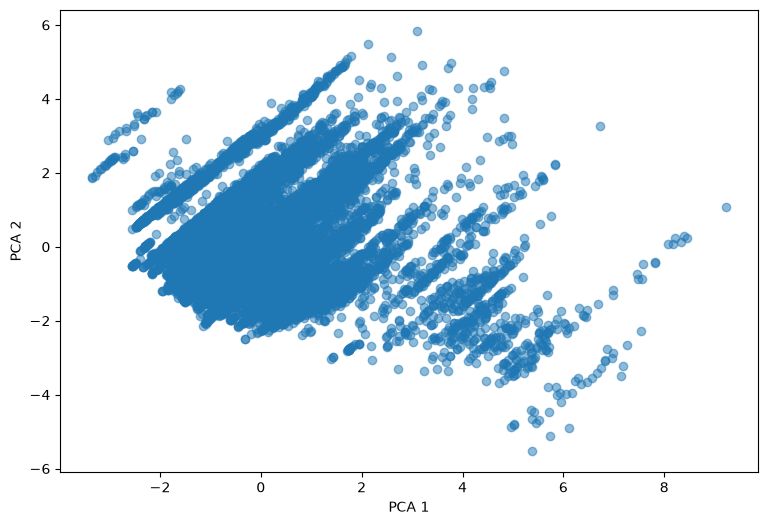

In [465]:
plt.figure(figsize=(9, 6))

plt.scatter(X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.5)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

t-sne

In [466]:
sample_size = min(5000, len(X_scaled))
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled),
    size=sample_size,
    replace=False)

X_sample = X_scaled[sample_indices]

In [467]:
tsne = TSNE(n_components=2,
    random_state=42,
    perplexity=30)

X_tsne = tsne.fit_transform(X_sample)

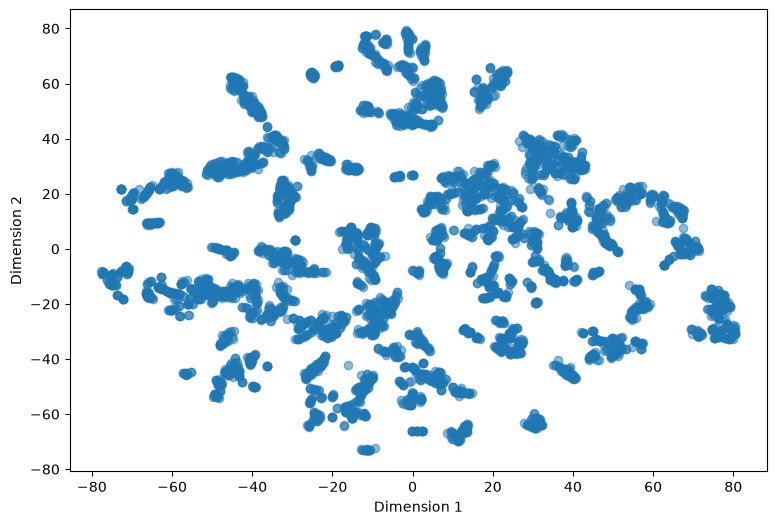

In [468]:
plt.figure(figsize=(9, 6))
plt.scatter(X_tsne[:, 0],
    X_tsne[:, 1],
    alpha=0.5)

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()

count    1.558800e+04
mean     1.328410e+09
std      1.976430e+09
min     -1.000000e+00
25%      3.950000e+08
50%      6.650000e+08
75%      1.390000e+09
max      3.000000e+10
Name: price, dtype: float64


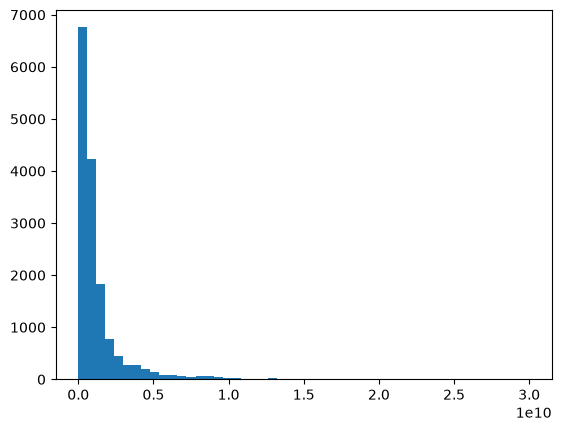

In [469]:
print(df["price"].describe())
plt.hist(df["price"], bins=50)
plt.show()

phase 3

In [470]:
selected_features = ['year', 'mileage', 'fuel', 'volume','acceleration']
X = df[features].copy()
X = scaler.fit_transform(X)
y = df["price"]

In [471]:
inertias = []

for k in range(2,11):
        kmeans_model = KMeans(n_clusters = k,
        random_state =42,
        n_init = 10)
        kmeans_model.fit(X)
        inertias.append(kmeans_model.inertia_)

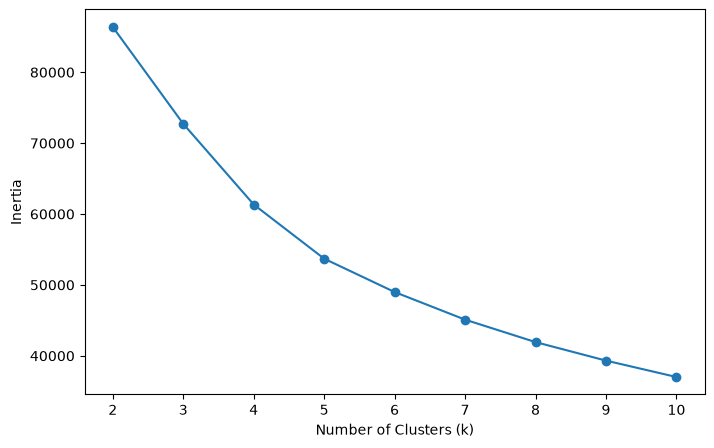

In [472]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertias, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.show()

In [473]:
k = 7

In [474]:
kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(
    df.groupby('Cluster')[['price']].mean()
)

                price
Cluster              
0        4.260146e+09
1        1.163795e+09
2        3.504362e+09
3        6.013937e+08
4        4.463912e+08
5        7.733981e+08
6        1.623172e+09


In [475]:
cluster_summary = df.groupby("Cluster")[selected_features + ["price"]].mean()

cluster_summary

,year,mileage,fuel,volume,acceleration,price
Cluster,,,,,,
0,1389.065954,195817.299465,10.782353,3.486809,8.520143,4.260146e+09
1,1398.346766,64213.546224,7.267592,1.630217,11.651879,1.163795e+09
2,1394.276063,112351.618432,7.922394,2.128824,9.509299,3.504362e+09
3,1397.651510,87884.847981,7.031490,1.591754,12.187445,6.013937e+08
4,1386.743636,290434.463153,7.333854,1.614917,12.114873,4.463912e+08
5,1397.855313,80635.327562,7.196727,1.585508,12.327728,7.733981e+08
6,1388.299270,182787.427007,13.004745,2.530292,15.948540,1.623172e+09


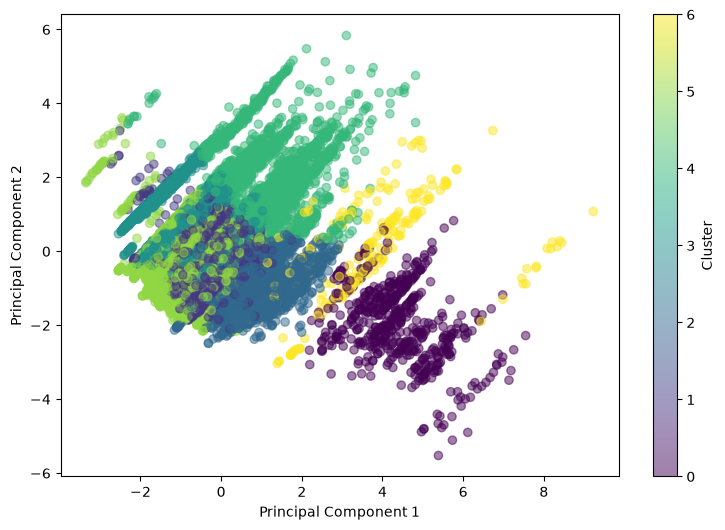

In [476]:
plt.figure(figsize=(9, 6))

plt.scatter(X_pca[:, 0],
    X_pca[:, 1],
    c=df["Cluster"],
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.show()

Regeression

In [477]:
y = df["price"]/1e6
regression_features = [
    "year",
    "mileage",
    "fuel",
    "volume",
    "acceleration",
    "automatic",
    "geer",
    "title",
    "type",
    "Cluster"
]
X = df[regression_features]

X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [478]:
models = {"Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, max_iter=10000),
    "Random Forest": RandomForestRegressor(n_estimators=100,random_state=42,min_samples_split=2,
        min_samples_leaf=1,
        n_jobs=-1
    )}

In [479]:
results = []

for name, model in models.items():

    if name in ["Ridge", "Lasso"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "MAE": mae,
    })

In [480]:
results_df = pd.DataFrame(results)
results_df

,Model,MSE,RMSE,R2,MAE
0,Linear Regression,2.218958e+06,1489.616755,0.467507,802.243055
1,Ridge,2.208385e+06,1486.063501,0.470044,797.689109
2,Lasso,2.208406e+06,1486.070697,0.470039,797.644025
3,Random Forest,1.806552e+05,425.035517,0.956647,132.984397


In [481]:
best_model = models["Random Forest"]

y_pred = best_model.predict(X_test)

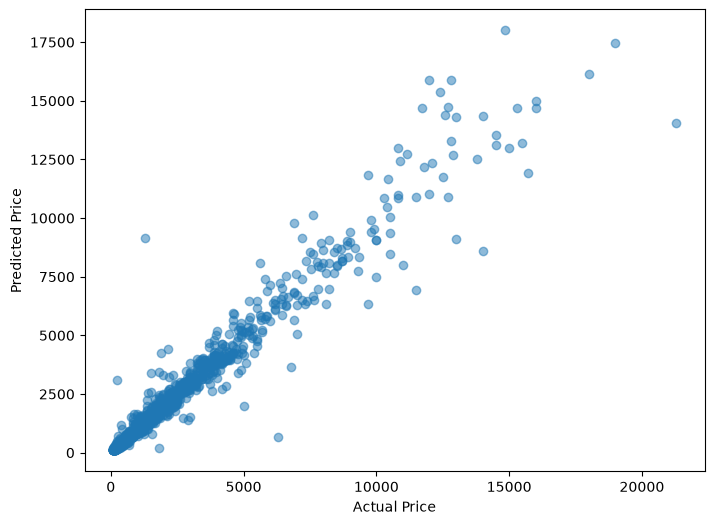

In [482]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [483]:
median_price = df["price"].median()
df["Is_Expensive"] = (df["price"] > median_price).astype(int)

df["Is_Expensive"].value_counts()

KeyError: 'price'

In [428]:
classification_features = ["mileage", "fuel", "volume", "acceleration", "year", "Cluster"]
X = df[classification_features]
y = df["Is_Expensive"]

In [429]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [430]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [431]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

In [432]:
classification_results = []

for name, model in classifiers.items():

    if name == "Decision Tree":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

In [433]:
classification_results_df = pd.DataFrame(classification_results)

classification_results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.815266,0.823958,0.800643,0.812133
1,KNN,0.941950,0.946684,0.936334,0.941481
2,SVM,0.896729,0.932025,0.855305,0.892019
3,Decision Tree,0.939384,0.944661,0.933119,0.938855


In [434]:
median_price = df["price"].median()

df["Is_Expensive"] = (df["price"] > median_price).astype(int)

print("Median price:", median_price)
print(df["Is_Expensive"].value_counts())

Median price: 665000000.0
Is_Expensive
0    7816
1    7772
Name: count, dtype: int64


In [435]:
knn = KNeighborsClassifier(n_neighbors=5)

cv_scores = cross_val_score(knn,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy")

print("CV scores:", cv_scores)
print("Mean CV acc:", cv_scores.mean())

Cross-validation scores: [0.92502005 0.93143545 0.93263833 0.92421812 0.92261427]
Mean CV accuracy: 0.9271852445870088


In [436]:
max_d = [3, 5, 10, None]
train_accuracies = []
test_accuracies = []

for depth in max_d:

    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)

    tree.fit(X_train, y_train)

    train_accuracy = tree.score(X_train, y_train)
    test_accuracy = tree.score(X_test, y_test)

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

print("Train accuracies:", train_accuracies)
print("Test accuracies:", test_accuracies)

Train accuracies: [0.8054530874097835, 0.8704891740176424, 0.9465116279069767, 0.9915797914995991]
Test accuracies: [0.813662604233483, 0.886144964720975, 0.9457985888389994, 0.9393842206542655]


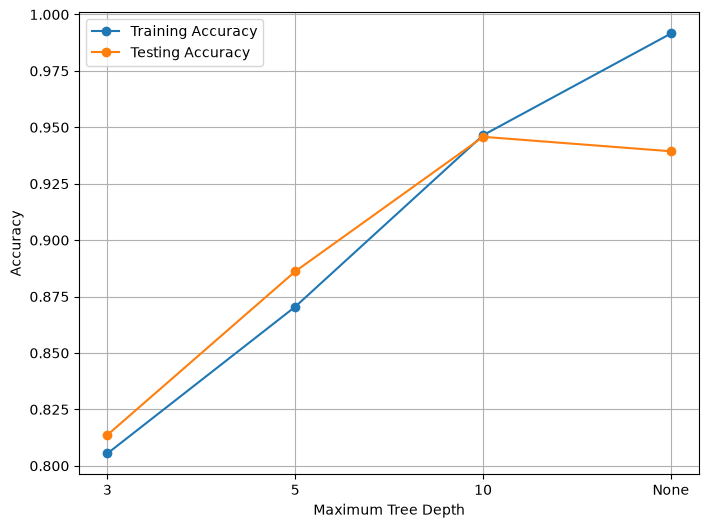

In [437]:
depth_labels = ["3", "5", "10", "None"]

plt.figure(figsize=(8, 6))

plt.plot(depth_labels,
    train_accuracies,
    marker="o",
    label="Training Accuracy")

plt.plot(depth_labels,
    test_accuracies,
    marker="o",
    label="Testing Accuracy")

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()